[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/snow0369/qiskit_handson_260827/blob/main/2_Introduction_to_Qiskit_Codealong_Client.ipynb)

# Introduction to Qiskit
- Initiatlizing circuit elements
- The Bell Circuit
- Running circuits on real hardware using Qiskit Runtime

## Importing libraries

In [ ]:
# Set variable to TRUE if you would like to enable automatic package installation and or upgrade throughout the script.
## This will update the packages within your current programming environment
automatic_package_install_upgrade = True


!pip install qiskit [visualization]
!pip install numpy
!pip install qiskit_ibm_runtime

In [ ]:
import qiskit
from qiskit_ibm_runtime import QiskitRuntimeService, Session, RuntimeJobV2, SamplerV2
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.quantum_info import Operator
import os

from qiskit.quantum_info import Statevector, random_statevector

import numpy as np

# Setting up Qiskit Runtime

You need to fill in token, instance information from https://quantum.cloud.ibm.com/

In [ ]:
# Paste your IBM Cloud credentials here. You only need to do this once per environment.
# After it works, you can comment these lines out so the credentials do not stay in the file.

token = ""
instance = ""

QiskitRuntimeService.save_account(
    token=token,
    instance=instance,
    overwrite=True,
    set_as_default=True,
)

# Verify
service = QiskitRuntimeService()
backends = service.backends()
print(f"Account OK. {len(backends)} backend(s) available:")
for b in backends[:5]:
    print(f"  {b.name} ({b.num_qubits} qubits)")

Account OK. 3 backend(s) available:
  ibm_fez (156 qubits)
  ibm_marrakesh (156 qubits)
  ibm_kingston (156 qubits)


# Backends and Primitives

Qiskit introduces abstractions called *primitives* for encapsulating the output of a quantum circuit. Currently, there are two primitives:
- **Sampler**: The output of the circuit is a (quasi-)probability distribution over measurement outcomes.
- **Estimator**: The output of the circuit is the expectation value of an observable, which must be provided in addition to the circuit.

Within Qiskit and the Qiskit Ecosystem, there are various concrete implementations of the primitives:
- **Reference primitives** included with [Qiskit](https://github.com/Qiskit/qiskit). These are useful for simulating the results of running small quantum circuits.
- **Runtime primitives** included with [Qiskit IBM Runtime](https://github.com/Qiskit/qiskit-ibm-runtime). These primitives are backed by real IBM Quantum hardware.
- Primitives in [Qiskit Aer](https://github.com/Qiskit/qiskit-aer). These primitives are backed by a high-performance quantum circuit simulator, and can handle larger circuits than the reference primitives and also model the effects of noise.

# Creating a basic circuit

The QuantumCircuit is the fundamental building block you will be using to build your circuits. <br>
The QuantumRegister also helps maintain a register of all the qubits you will be using, and the ClassicalRegister is the register for the classical bits you will be using.

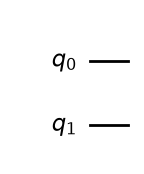

In [ ]:
# Define your qubits using the QuantumRegister library function
#qubits = QuantumRegister('<insert number of qubits>')

qubits = QuantumRegister(2, name="q")

circuit=QuantumCircuit(qubits)

circuit.draw("mpl")

In [ ]:
# Add operations to the circuit

q0,q1= qubits
circuit.
circuit.

circuit.draw("mpl")

# Creating a 2 Qubit Bell circuit

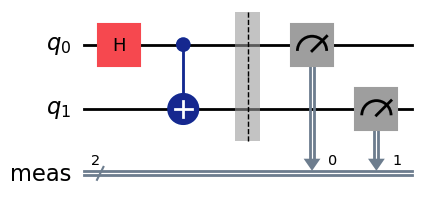

In [ ]:
#Initialize a register of qubits.
#Make a bell state circuit with two qubits and measure it.

qubits=QuantumRegister(2, name="q")
circuit=QuantumCircuit(qubits)

q0,q1=qubits
circuit.

# Running on Real Quantum Hardware using Qiskit Runtime w/ out Optimization
The `Session` object allows us to group together a collection of iterative calls to the quantum computer and is started once the first job within the session is executed.  Subsequent jobs will then be prioritized in the queue.

In [ ]:
service = QiskitRuntimeService()
#selected_backend = service.backend("ibm_kingston") # If a specific machine is desired
selected_backend = service.least_busy(operational=True, simulator=False)

In [ ]:
print(selected_backend)
# alternatively, choose your backend
# selected_backend = service.backend("ibm_kingston")

In [ ]:
# Create a Bell Circuit with ClassicalRegister

qr=
cr=
qc=

In [ ]:
from qiskit.transpiler import generate_preset_pass_manager

#pm = generate_preset_pass_manager(backend=selected_backend, optimization_level="<insert integer here for optimization level>") # from 1 to 3 -- 3 being most optimized, but takes longest
pm = generate_preset_pass_manager(backend=selected_backend, optimization_level=1) # from 0 to 3 -- 3 being most optimized, but takes longest


In [ ]:
#Transpile
transpiled_circuit = pm.run(circuit)

In [ ]:
#Display circuit diagram
display(circuit.draw(output="mpl"))
display(transpiled_circuit.draw('mpl', idle_wires=False))

In [ ]:
#Sample Circuit
sampler = SamplerV2(mode=selected_backend)

job = sampler.run([(transpiled_circuit)],shots=)
pub_result = job.result()[0]

## Displaying Results

In [ ]:
plot_histogram(pub_result.data.cr.get_counts())

In [ ]:
print(f"Sampler job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")
print(f"Counts: {pub_result.data.cr.get_counts()}")
# print(f"  > Quasi-probability distribution (integer): {pub_result[0].data.meas.get_counts()}")
# print(f"  > Metadata: {result.metadata}")


**What are Bell states?**

---


Bell states are quantum states of two qubits that represent simple examples of **quantum entanglement**. When one of the two qubits is measured, it takes on a specific value, and the second qubit is forced to also take on a specific value, as the entangled state collapses.


# Changing the optimization levels
Showing power of Qiskit Optimization Process, it changes the circuit size (from bigger to smaller)
Applying error mitigation

In [ ]:
pm = generate_preset_pass_manager(backend=selected_backend, optimization_level=) # opt_lev= 3

In [ ]:
transpiled_circuit = pm.run(qc)
display(qc.draw(output="mpl"))
display(transpiled_circuit.draw('mpl', idle_wires=False))


In [ ]:
sampler = SamplerV2(mode=selected_backend)

job = sampler.run([(transpiled_circuit)],shots=)
pub_result = job.result()[0]
    # Primitive Unitary Bloc -- sweeps observables, parameters, circuits in an efficient, vectorized way
    # print(f"Sampler job ID: {job.job_id()}")
    # print(f">>> Job Status: {job.status()}")
    # print(f"Counts: {pub_result.data.cr.get_counts()}")
    # print(f"  > Quasi-probability distribution (integer): {pub_result.data.meas.get_counts()}")
    # print(f"  > Metadata: {result.metadata}")

In [ ]:
print(f"Sampler job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")
print(f"Counts: {pub_result.data.cr.get_counts()}")
# print(f"  > Quasi-probability distribution (integer): {pub_result[0].data.meas.get_counts()}")
# print(f"  > Metadata: {result.metadata}")

Sampler job ID: d50m9l1smlfc739c25lg
>>> Job Status: DONE
Counts: {'00': 2112, '11': 1913, '10': 39, '01': 32}


In [ ]:
plot_histogram(pub_result.data.cr.get_counts())